In [1]:
"""
Этап 6. Интерпретация и стратегии управления.

Для каждой из 9 групп ABC/XYZ — конкретная стратегия:
- что делать с запасами,
- как планировать закупки,
- какие риски,
- что проверять.
"""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

from scripts.db_config import read_sql

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)

REPORTS_DIR = ROOT_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

print("✅ Окружение готово")

✅ Окружение готово


In [2]:
abc_xyz = read_sql("""
    SELECT *
    FROM abc_xyz
    ORDER BY abc_xyz, revenue DESC;
""")
abc_xyz["revenue"] = abc_xyz["revenue"].astype(float)
abc_xyz["cv"] = abc_xyz["cv"].astype(float)

# Сводка по группам с доп. метриками
summary = (
    abc_xyz.groupby("abc_xyz")
    .agg(
        skus=("stock_code", "count"),
        revenue=("revenue", "sum"),
        quantity=("total_quantity", "sum"),
        orders=("orders", "sum"),
        customers=("customers", "sum"),
        avg_cv=("cv", "mean"),
        median_cv=("cv", "median"),
        avg_active_months=("active_months", "mean"),
    )
)

summary["sku_share_pct"] = summary["skus"] / summary["skus"].sum() * 100
summary["revenue_share_pct"] = summary["revenue"] / summary["revenue"].sum() * 100

# Упорядочим для отображения
order = ["AX", "AY", "AZ", "A-no_data", "BX", "BY", "BZ", "CX", "CY", "CZ"]
summary = summary.reindex([c for c in order if c in summary.index])

print("Сводка по группам с метриками CV и активных месяцев:")
display(summary[[
    "skus", "sku_share_pct", "revenue", "revenue_share_pct",
    "avg_cv", "median_cv", "avg_active_months",
]].round(2))

Сводка по группам с метриками CV и активных месяцев:


,skus,sku_share_pct,revenue,revenue_share_pct,avg_cv,median_cv,avg_active_months
abc_xyz,,,,,,,
AX,110,2.25,"2,883,259.37",14.34,0.41,0.41,24.82
AY,408,8.34,"7,068,488.82",35.15,0.73,0.72,23.15
AZ,516,10.54,"5,965,998.53",29.67,1.71,1.54,15.17
A-no_data,1,0.02,"168,469.60",0.84,NaN,NaN,1.00
BX,16,0.33,"48,100.13",0.24,0.41,0.42,24.81
BY,250,5.11,"619,843.37",3.08,0.79,0.80,23.11
BZ,1012,20.67,"2,348,611.53",11.68,1.91,1.70,14.81
CX,1,0.02,897.12,0.00,0.47,0.47,25.00
CY,155,3.17,"97,955.78",0.49,0.85,0.87,22.03


In [3]:
# Словарь стратегий
STRATEGIES = {
    "AX": {
        "name": "Стабильное ядро",
        "priority": "Критический",
        "strategy": "Постоянное наличие, автозаказ",
        "action": (
            "Неснижаемый запас, автоматический заказ при остатке < X ед. "
            "Приоритет в поставках. Никогда не допускать дефицита."
        ),
    },
    "AY": {
        "name": "Сезонные лидеры",
        "priority": "Высокий",
        "strategy": "Планирование с учётом сезонности",
        "action": (
            "Запас с учётом сезонных пиков (ноя-дек). Отдельные пиковые заказы, "
            "снижение запаса в межсезонье (март-сентябрь)."
        ),
    },
    "AZ": {
        "name": "Рискованные лидеры",
        "priority": "Высокий (осторожно)",
        "strategy": "Закупка под спрос, минимальный запас",
        "action": (
            "Закупка под конкретные заказы, минимальный склад. "
            "Проверять сезонность vs хаос. Избегать приоритета в наличии."
        ),
    },
    "A-no_data": {
        "name": "Недостаточно истории",
        "priority": "Наблюдение",
        "strategy": "Сбор данных",
        "action": (
            "Не менять поведение закупок. Продолжать наблюдение. "
            "Один заказ — не показатель спроса."
        ),
    },
    "BX": {
        "name": "Средний стабильный",
        "priority": "Средний",
        "strategy": "Стандартное управление",
        "action": (
            "Обычный запас по графику. Проверить 1 раз в квартал. "
            "Кандидаты на переход в A по мере роста спроса."
        ),
    },
    "BY": {
        "name": "Средний сезонный",
        "priority": "Средний",
        "strategy": "Умеренно осторожное планирование",
        "action": (
            "Запас с учётом сезонности. Периодический пересмотр."
        ),
    },
    "BZ": {
        "name": "Средний нестабильный",
        "priority": "Средний (проверить)",
        "strategy": "Ограниченный запас",
        "action": (
            "Ограниченный запас или закупка под заказ. "
            "Пересматривать ассортимент каждые полгода."
        ),
    },
    "CX": {
        "name": "Малый стабильный",
        "priority": "Низкий, но сохранить",
        "strategy": "Не удалять, проверить роль",
        "action": (
            "Сохранить, проверить роль в корзине (basket analysis). "
            "Возможен товар-локомотив для других покупок."
        ),
    },
    "CY": {
        "name": "Малый сезонный",
        "priority": "Низкий",
        "strategy": "Проверить дополнительные метрики",
        "action": (
            "Проверить сезонность, роль в ассортименте. "
            "Кандидат на ограниченный запас или вывод (по результатам проверки)."
        ),
    },
    "CZ": {
        "name": "Малый нестабильный",
        "priority": "Низкий, кандидат на вывод",
        "strategy": "Основной пул для проверки",
        "action": (
            "Проверить: кол-во клиентов, роль в корзине, возраст товара. "
            "Исключить новые, сезонные, товары с большой клиентской базой. "
            "Остальные — кандидаты на вывод."
        ),
    },
}

# Преобразуем в DataFrame
strategy_df = pd.DataFrame([
    {"abc_xyz": k, **v}
    for k, v in STRATEGIES.items()
    if k in summary.index
])

# Присоединяем метрики
strategy_df = strategy_df.merge(
    summary[["skus", "sku_share_pct", "revenue_share_pct"]],
    on="abc_xyz", how="left"
)

print("Стратегии управления по группам:")
display(strategy_df[[
    "abc_xyz", "name", "priority", "strategy",
    "skus", "sku_share_pct", "revenue_share_pct",
]])

Стратегии управления по группам:


,abc_xyz,name,priority,strategy,skus,sku_share_pct,revenue_share_pct
0,AX,Стабильное ядро,Критический,"Постоянное наличие, автозаказ",110,2.25,14.34
1,AY,Сезонные лидеры,Высокий,Планирование с учётом сезонности,408,8.34,35.15
2,AZ,Рискованные лидеры,Высокий (осторожно),"Закупка под спрос, минимальный запас",516,10.54,29.67
3,A-no_data,Недостаточно истории,Наблюдение,Сбор данных,1,0.02,0.84
4,BX,Средний стабильный,Средний,Стандартное управление,16,0.33,0.24
5,BY,Средний сезонный,Средний,Умеренно осторожное планирование,250,5.11,3.08
6,BZ,Средний нестабильный,Средний (проверить),Ограниченный запас,1012,20.67,11.68
7,CX,Малый стабильный,"Низкий, но сохранить","Не удалять, проверить роль",1,0.02,0.00
8,CY,Малый сезонный,Низкий,Проверить дополнительные метрики,155,3.17,0.49
9,CZ,Малый нестабильный,"Низкий, кандидат на вывод",Основной пул для проверки,2426,49.56,4.51


In [4]:
# Словарь стратегий
STRATEGIES = {
    "AX": {
        "name": "Стабильное ядро",
        "priority": "Критический",
        "strategy": "Постоянное наличие, автозаказ",
        "action": (
            "Неснижаемый запас, автоматический заказ при остатке < X ед. "
            "Приоритет в поставках. Никогда не допускать дефицита."
        ),
    },
    "AY": {
        "name": "Сезонные лидеры",
        "priority": "Высокий",
        "strategy": "Планирование с учётом сезонности",
        "action": (
            "Запас с учётом сезонных пиков (ноя-дек). Отдельные пиковые заказы, "
            "снижение запаса в межсезонье (март-сентябрь)."
        ),
    },
    "AZ": {
        "name": "Рискованные лидеры",
        "priority": "Высокий (осторожно)",
        "strategy": "Закупка под спрос, минимальный запас",
        "action": (
            "Закупка под конкретные заказы, минимальный склад. "
            "Проверять сезонность vs хаос. Избегать приоритета в наличии."
        ),
    },
    "A-no_data": {
        "name": "Недостаточно истории",
        "priority": "Наблюдение",
        "strategy": "Сбор данных",
        "action": (
            "Не менять поведение закупок. Продолжать наблюдение. "
            "Один заказ — не показатель спроса."
        ),
    },
    "BX": {
        "name": "Средний стабильный",
        "priority": "Средний",
        "strategy": "Стандартное управление",
        "action": (
            "Обычный запас по графику. Проверить 1 раз в квартал. "
            "Кандидаты на переход в A по мере роста спроса."
        ),
    },
    "BY": {
        "name": "Средний сезонный",
        "priority": "Средний",
        "strategy": "Умеренно осторожное планирование",
        "action": (
            "Запас с учётом сезонности. Периодический пересмотр."
        ),
    },
    "BZ": {
        "name": "Средний нестабильный",
        "priority": "Средний (проверить)",
        "strategy": "Ограниченный запас",
        "action": (
            "Ограниченный запас или закупка под заказ. "
            "Пересматривать ассортимент каждые полгода."
        ),
    },
    "CX": {
        "name": "Малый стабильный",
        "priority": "Низкий, но сохранить",
        "strategy": "Не удалять, проверить роль",
        "action": (
            "Сохранить, проверить роль в корзине (basket analysis). "
            "Возможен товар-локомотив для других покупок."
        ),
    },
    "CY": {
        "name": "Малый сезонный",
        "priority": "Низкий",
        "strategy": "Проверить дополнительные метрики",
        "action": (
            "Проверить сезонность, роль в ассортименте. "
            "Кандидат на ограниченный запас или вывод (по результатам проверки)."
        ),
    },
    "CZ": {
        "name": "Малый нестабильный",
        "priority": "Низкий, кандидат на вывод",
        "strategy": "Основной пул для проверки",
        "action": (
            "Проверить: кол-во клиентов, роль в корзине, возраст товара. "
            "Исключить новые, сезонные, товары с большой клиентской базой. "
            "Остальные — кандидаты на вывод."
        ),
    },
}

# Преобразуем в DataFrame
strategy_df = pd.DataFrame([
    {"abc_xyz": k, **v}
    for k, v in STRATEGIES.items()
    if k in summary.index
])

# Присоединяем метрики
strategy_df = strategy_df.merge(
    summary[["skus", "sku_share_pct", "revenue_share_pct"]],
    on="abc_xyz", how="left"
)

print("Стратегии управления по группам:")
display(strategy_df[[
    "abc_xyz", "name", "priority", "strategy",
    "skus", "sku_share_pct", "revenue_share_pct",
]])

Стратегии управления по группам:


,abc_xyz,name,priority,strategy,skus,sku_share_pct,revenue_share_pct
0,AX,Стабильное ядро,Критический,"Постоянное наличие, автозаказ",110,2.25,14.34
1,AY,Сезонные лидеры,Высокий,Планирование с учётом сезонности,408,8.34,35.15
2,AZ,Рискованные лидеры,Высокий (осторожно),"Закупка под спрос, минимальный запас",516,10.54,29.67
3,A-no_data,Недостаточно истории,Наблюдение,Сбор данных,1,0.02,0.84
4,BX,Средний стабильный,Средний,Стандартное управление,16,0.33,0.24
5,BY,Средний сезонный,Средний,Умеренно осторожное планирование,250,5.11,3.08
6,BZ,Средний нестабильный,Средний (проверить),Ограниченный запас,1012,20.67,11.68
7,CX,Малый стабильный,"Низкий, но сохранить","Не удалять, проверить роль",1,0.02,0.00
8,CY,Малый сезонный,Низкий,Проверить дополнительные метрики,155,3.17,0.49
9,CZ,Малый нестабильный,"Низкий, кандидат на вывод",Основной пул для проверки,2426,49.56,4.51


C:\Users\LaSh\AppData\Local\Temp\ipykernel_19224\2063076778.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  color_numeric = priority_matrix.applymap(lambda x: color_map.get(x, 5))
C:\Users\LaSh\AppData\Local\Temp\ipykernel_19224\2063076778.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("RdYlGn_r", 8)


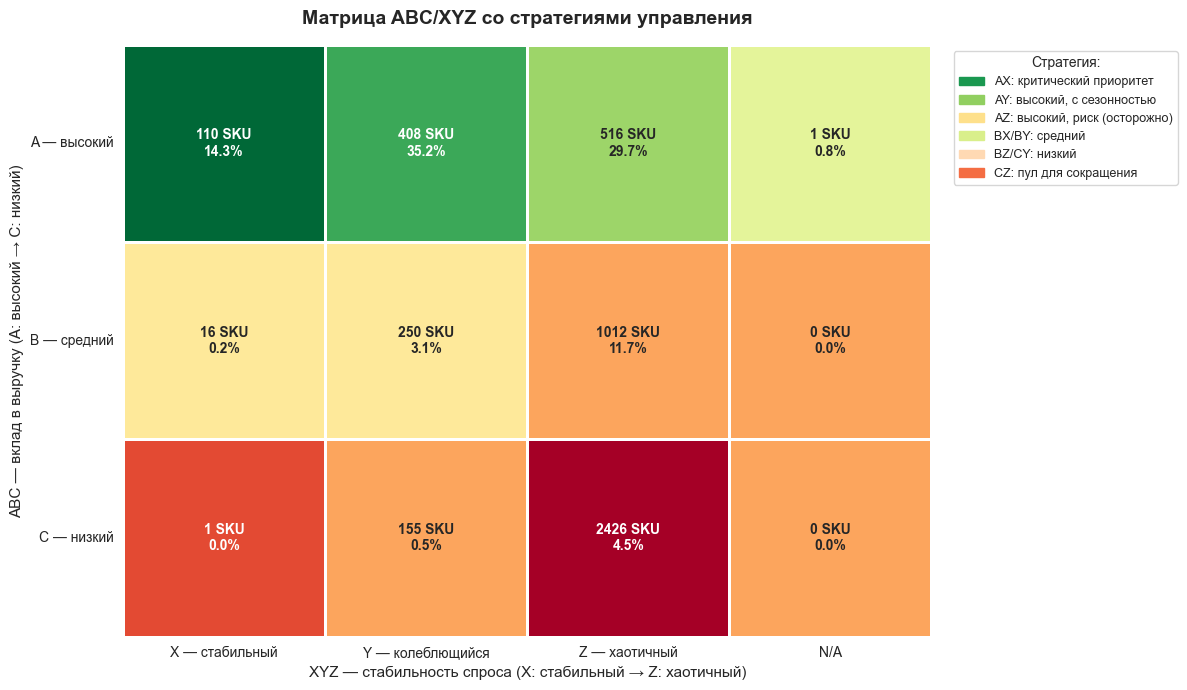

In [8]:
# Матрица: ABC на Y, XYZ на X
revenue_matrix = abc_xyz.pivot_table(
    index="abc_category",
    columns="xyz_category",
    values="revenue",
    aggfunc="sum",
    fill_value=0,
)
revenue_matrix = revenue_matrix.reindex(
    index=["A", "B", "C"],
    columns=["X", "Y", "Z", "N/A"],
    fill_value=0,
)
revenue_pct = revenue_matrix / revenue_matrix.sum().sum() * 100

# Аналогично для SKU
sku_matrix = abc_xyz.pivot_table(
    index="abc_category",
    columns="xyz_category",
    values="stock_code",
    aggfunc="count",
    fill_value=0,
).reindex(index=["A", "B", "C"], columns=["X", "Y", "Z", "N/A"], fill_value=0)

# Формируем аннотации
annot = sku_matrix.astype(str) + " SKU\n" + revenue_pct.round(1).astype(str) + "%"

# Присваиваем приоритет для цветовой схемы
priority_matrix = pd.DataFrame(index=["A", "B", "C"], columns=["X", "Y", "Z", "N/A"])
priority_matrix.loc["A", "X"] = "critical"   # зелёный
priority_matrix.loc["A", "Y"] = "high"       # светло-зелёный
priority_matrix.loc["A", "Z"] = "high_risk"  # оранжевый
priority_matrix.loc["A", "N/A"] = "warn"     # жёлтый
priority_matrix.loc["B", "X"] = "medium"
priority_matrix.loc["B", "Y"] = "medium"
priority_matrix.loc["B", "Z"] = "low"
priority_matrix.loc["C", "X"] = "special"    # серый
priority_matrix.loc["C", "Y"] = "low"
priority_matrix.loc["C", "Z"] = "lowest"     # красный

# Числовая карта для раскраски
color_map = {
    "critical": 0, "high": 1, "high_risk": 2, "warn": 3,
    "medium": 4, "low": 5, "special": 6, "lowest": 7,
}
color_numeric = priority_matrix.applymap(lambda x: color_map.get(x, 5))

fig, ax = plt.subplots(figsize=(12, 7))

cmap = plt.cm.get_cmap("RdYlGn_r", 8)
sns.heatmap(
    color_numeric,
    annot=annot.values,
    fmt="",
    cmap=cmap,
    cbar=False,
    linewidths=2,
    linecolor="white",
    ax=ax,
    annot_kws={"fontsize": 10, "fontweight": "bold"},
)

ax.set_title("Матрица ABC/XYZ со стратегиями управления",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("XYZ — стабильность спроса (X: стабильный → Z: хаотичный)",
              fontsize=11)
ax.set_ylabel("ABC — вклад в выручку (A: высокий → C: низкий)", fontsize=11)
ax.set_xticklabels(["X — стабильный", "Y — колеблющийся", "Z — хаотичный", "N/A"],
                    rotation=0, fontsize=10)
ax.set_yticklabels(["A — высокий", "B — средний", "C — низкий"],
                    rotation=0, fontsize=10)

# Легенда
legend_elements = [
    mpatches.Patch(color="#1a9850", label="AX: критический приоритет"),
    mpatches.Patch(color="#91cf60", label="AY: высокий, с сезонностью"),
    mpatches.Patch(color="#fee08b", label="AZ: высокий, риск (осторожно)"),
    mpatches.Patch(color="#d9ef8b", label="BX/BY: средний"),
    mpatches.Patch(color="#ffd9b3", label="BZ/CY: низкий"),
    mpatches.Patch(color="#f46d43", label="CZ: пул для сокращения"),
]
ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=9,
    title="Стратегия:",
)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "abc_xyz_strategy_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

In [6]:
print("=" * 100)
print("ГРАНИЦА AY vs AZ — что важно понимать")
print("=" * 100)

border = read_sql("""
    SELECT
        stock_code, description, abc_xyz, revenue,
        orders, customers, active_months, cv
    FROM abc_xyz
    WHERE abc_xyz IN ('AY', 'AZ')
      AND revenue > 50000
    ORDER BY revenue DESC;
""")
border["revenue"] = border["revenue"].astype(float)
border["cv"] = border["cv"].astype(float)

print("SKU с выручкой > £50k в AY и AZ:")
display(border)

ГРАНИЦА AY vs AZ — что важно понимать
SKU с выручкой > £50k в AY и AZ:


,stock_code,description,abc_xyz,revenue,orders,customers,active_months,cv
0,22423,REGENCY CAKESTAND 3 TIER,AY,"344,563.25",3918,1314,22,0.62
1,47566,PARTY BUNTING,AY,"149,187.05",2674,894,25,0.72
2,84879,ASSORTED COLOUR BIRD ORNAMENT,AY,"132,187.92",2807,1010,25,0.55
3,22086,PAPER CHAIN KIT 50'S CHRISTMAS,AZ,"123,141.54",2018,896,24,1.55
4,79321,CHILLI LIGHTS,AY,"85,489.91",1135,304,25,0.91
5,23166,MEDIUM CERAMIC TOP STORAGE JAR,AZ,"81,700.92",247,138,9,4.56
6,22197,SMALL POPCORN HOLDER,AY,"80,920.64",2322,601,25,0.79
7,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,AZ,"74,448.92",756,300,24,2.03
8,21137,BLACK RECORD COVER FRAME,AY,"69,329.47",634,198,25,0.91
9,20685,RED SPOTTY COIR DOORMAT,AY,"67,859.56",1725,626,25,0.54


Топ-6 AZ для анализа сезонности:


,stock_code,description,revenue,cv
519,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"123,141.54",1.55
520,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",4.56
521,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"74,448.92",2.03
522,23084,RABBIT NIGHT LIGHT,"66,964.99",2.88
523,22114,HOT WATER BOTTLE TEA AND SYMPATHY,"63,517.75",1.28
524,82484,WOOD BLACK BOARD ANT WHITE FINISH,"62,842.02",1.10


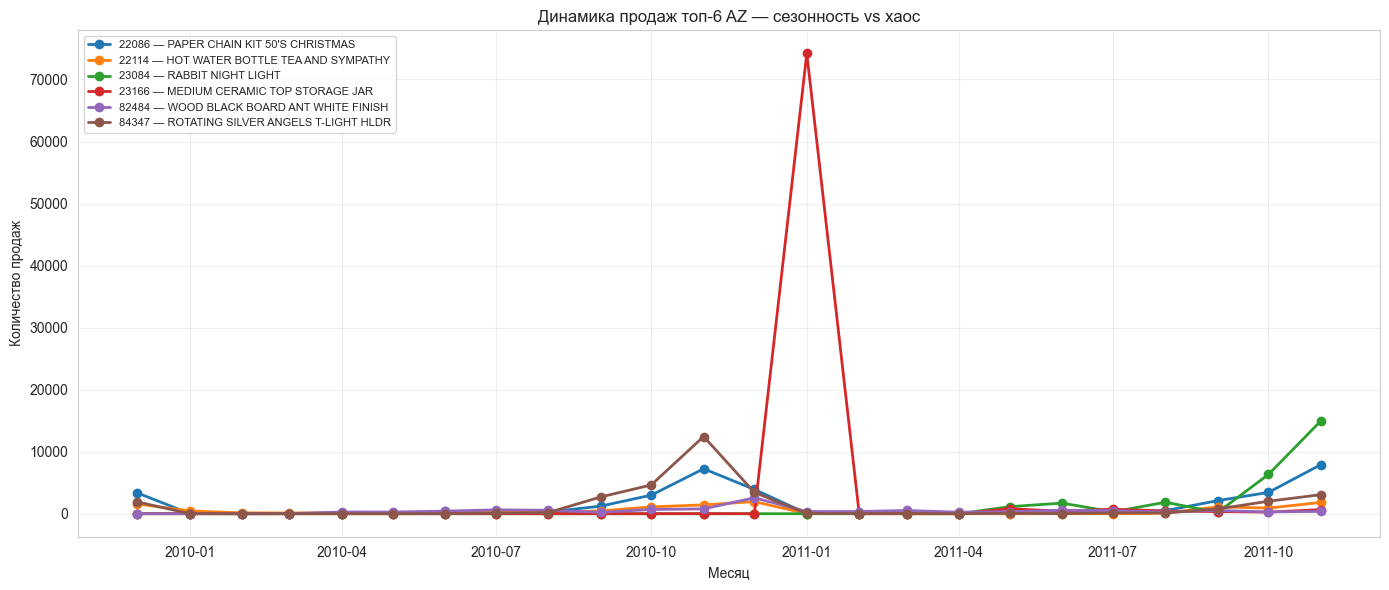

In [7]:
# Для нескольких топовых AZ-товаров построим временные ряды
top_az = (
    abc_xyz[abc_xyz["abc_xyz"] == "AZ"]
    .nlargest(6, "revenue")
)
print("Топ-6 AZ для анализа сезонности:")
display(top_az[["stock_code", "description", "revenue", "cv"]])

# Забираем их месячные данные
top_az_codes = tuple(top_az["stock_code"].tolist())
codes_sql = ", ".join(f"'{c}'" for c in top_az_codes)

monthly = read_sql(f"""
    SELECT
        stock_code,
        month_start,
        SUM(quantity) AS qty
    FROM sales
    WHERE stock_code IN ({codes_sql})
      AND month_start < DATE '2011-12-01'
    GROUP BY stock_code, month_start
    ORDER BY stock_code, month_start;
""")
monthly["month_start"] = pd.to_datetime(monthly["month_start"])

# Pivot и график
pivot = monthly.pivot_table(
    index="month_start", columns="stock_code",
    values="qty", aggfunc="sum", fill_value=0,
)

fig, ax = plt.subplots(figsize=(14, 6))
for col in pivot.columns:
    desc = top_az[top_az["stock_code"] == col]["description"].iloc[0]
    label = f"{col} — {desc[:40]}"
    ax.plot(pivot.index, pivot[col], marker="o", linewidth=2, label=label)

ax.set_xlabel("Месяц")
ax.set_ylabel("Количество продаж")
ax.set_title("Динамика продаж топ-6 AZ — сезонность vs хаос")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "az_seasonality_check.png", dpi=120, bbox_inches="tight")
plt.show()

## Этап 6. Стратегии управления — ВЫВОДЫ (финал)

### Матрица с приоритетами

| Группа | SKU | % SKU | % выручки | avg CV | avg active months | Стратегия |
|--------|-----|-------|-----------|--------|-------------------|-----------|
| **AX** | 110 | 2.25% | 14.34% | 0.41 | **24.8** | Постоянный запас, автозаказ |
| **AY** | 408 | 8.34% | **35.15%** | 0.73 | 23.2 | Сезонное планирование |
| **AZ** | 516 | 10.54% | **29.67%** | 1.71 | **15.2** | Закупка под заказ |
| A-no_data | 1 | 0.02% | 0.84% | — | 1.0 | Наблюдение |
| **BX** | 16 | 0.33% | 0.24% | 0.41 | 24.8 | Стандарт |
| **BY** | 250 | 5.11% | 3.08% | 0.79 | 23.1 | Умеренно осторожное |
| **BZ** | 1 012 | 20.67% | 11.68% | 1.91 | 14.8 | Ограниченный запас |
| **CX** | 1 | 0.02% | 0.00% | 0.47 | 25.0 | Проверить роль |
| **CY** | 155 | 3.17% | 0.49% | 0.85 | 22.0 | Проверить метрики |
| **CZ** | **2 426** | **49.56%** | 4.51% | **2.65** | **9.2** | **Пул для сокращения** |

### Ключевые выводы

1. **Ядро бизнеса (AX + AY) — 518 SKU (10.6%) дают 49.49% выручки.**
   Средний CV = 0.41 и 0.73, средние активные месяцы = 23–25.
   Эти товары продаются почти каждый месяц. Приоритет №1.

2. **AZ (516 SKU, 29.67% выручки) — критичная зона.**
   Средний CV = 1.71, средние активные месяцы = **15 из 24**.
   Эти товары **нельзя планировать по среднему**. Только под заказ.
   Примеры:
   - **23166 MEDIUM CERAMIC TOP STORAGE JAR** — CV 4.56, 9 месяцев.
     Одна крупная закупка в янв-2011, ноль остальное время.
   - **23084 RABBIT NIGHT LIGHT** — CV 2.88, 8 месяцев. Сезонный.
   - **22086 PAPER CHAIN KIT 50'S CHRISTMAS** — CV 1.55. Сезонный.

3. **CZ (2 426 SKU, 49.56% ассортимента) — основной пул для сокращения.**
   Средний CV = 2.65, средние активные месяцы = **9.2 из 24**.
   Половина ассортимента продаётся только треть времени и даёт 4.5% выручки.

4. **Анализ сезонности топ-6 AZ выявил 4 подтипа AZ:**
   - **AZ-сезонные** (22086 PAPER CHAIN KIT) — пик в ноя-дек, ноль летом.
     Стратегия: пиковый запас перед декабрём.
   - **AZ-новые растущие** (23084 RABBIT NIGHT LIGHT) — растут год к году.
     Стратегия: наблюдение, увеличение заказа по мере роста.
   - **AZ-разовые** (23166 CERAMIC JAR, 84347 ROTATING ANGELS) —
     один-два крупных пика, потом ноль. Стратегия: закупка под заказ.
   - **AZ-нишевые** (82484 WOOD BOARD) — низкий уровень, редкие всплески.
     Стратегия: минимальный запас.

5. **Отличие AY от AZ (критично для бизнеса):**
   - **AY** — предсказуемая сезонность. Планируем по прошлому году.
   - **AZ** — непредсказуемый спрос. Только под конкретный заказ.
   Средний CV AY = 0.73 vs средний CV AZ = 1.71 — разница в 2.3 раза.

6. **Группа CX (1 SKU)** — особый случай: низкая выручка, но
   стабильный спрос (25 месяцев). Требует ручной проверки.

7. **A-no_data (SKU 23843 PAPER CRAFT)** — формально A по выручке,
   но без истории XYZ. Не приоритет для закупок.

### Правила управления — сводная таблица

| Действие \ Группа | AX | AY | AZ | BX | BY | BZ | CX | CY | CZ |
|--------------------|----|----|----|----|----|----|----|----|-----|
| Постоянный запас | ✅ | ⚠️ | ❌ | ✅ | ⚠️ | ❌ | ✅ | ⚠️ | ❌ |
| Автозаказ | ✅ | ✅ | ❌ | ✅ | ⚠️ | ❌ | ✅ | ❌ | ❌ |
| Сезонное планирование | — | ✅ | ⚠️ | — | ✅ | — | — | ⚠️ | — |
| Закупка под заказ | ❌ | — | ✅ | — | — | ✅ | ❌ | — | ⚠️ |
| Пересмотр ассортимента | Нет | 1×год | 2×год | 1×год | 2×год | 2×год | 1×год | 1×год | 1×квартал |

### Что дальше

**Этап 7 (Список кандидатов на сокращение).**
Начнём с CZ (2 426 SKU). Применим дополнительные фильтры:
- Сколько клиентов? (>10 — сохранить)
- Есть ли повторные покупки?
- Возраст товара? (новые — не трогать)
- Сезонность?

Цель — безопасно сократить ~20% ассортимента (~980 SKU).

### Графики
- `reports/abc_xyz_strategy_matrix.png` — матрица стратегий.
- `reports/az_seasonality_check.png` — сезонность AZ.

In [9]:
"""
Сохранение таблицы strategies в Postgres.
"""
import psycopg2
from scripts.db_config import execute_sql, _get_conn_params

# Готовим DataFrame для сохранения
strategy_rows = strategy_df[[
    "abc_xyz", "name", "priority", "strategy", "action",
    "skus", "sku_share_pct", "revenue_share_pct",
]].copy()

# Пересоздаём таблицу
execute_sql("DROP TABLE IF EXISTS strategies;")
execute_sql("""
    CREATE TABLE strategies (
        abc_xyz           text PRIMARY KEY,
        name              text,
        priority          text,
        strategy          text,
        action            text,
        skus              integer,
        sku_share_pct     numeric,
        revenue_share_pct numeric
    );
""")

# Вставка через executemany
insert_sql = "INSERT INTO strategies VALUES (%s, %s, %s, %s, %s, %s, %s, %s);"
rows = [tuple(r) for r in strategy_rows.itertuples(index=False, name=None)]

with psycopg2.connect(**_get_conn_params()) as conn:
    with conn.cursor() as cur:
        cur.executemany(insert_sql, rows)
    conn.commit()

print(f"✅ Таблица strategies сохранена ({len(rows)} строк)")

✅ Таблица strategies сохранена (10 строк)
